# **Práctica Bloque II: Fundamentos de Arquitectura y Rendimiento en GPU**

## Computación de Altas Prestaciones (CAP)

## Universidad de Córdoba

# **1. Entorno de Ejecución y Análisis de la "Cubeta" (SM)**

El Streaming Multiprocessor (SM) es la unidad de cómputo de la GPU. Antes de optimizar, debemos conocer los límites físicos de nuestra "cubeta": cuántos registros y cuánta memoria compartida (Shared Memory) tenemos disponibles por SM.

In [116]:
!nvidia-smi

Wed Apr  1 14:36:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
%%writefile hardware_info.cu
#include <stdio.h>
#include <cuda_runtime.h>

int main() {
    int device;
    cudaGetDevice(&device);
    cudaDeviceProp prop;
    cudaGetDeviceProperties(&prop, device);

    printf("--- ANÁLISIS DETALLADO DEL SM Y MEMORIA ---\n");
    printf("GPU: %s\n", prop.name);

    printf("\n[1] Arquitectura del Streaming Multiprocessor (SM):\n");
    printf("- Número de SMs en la GPU: %d\n", prop.multiProcessorCount);
    printf("- Máximo de hilos por SM (Techo de la cubeta): %d\n", prop.maxThreadsPerMultiProcessor);
    printf("- Máximo de Warps por SM (Hilos/32): %d\n", prop.maxThreadsPerMultiProcessor / 32);
    printf("- Registros totales por SM: %d\n", prop.regsPerMultiprocessor);

    printf("\n[2] Jerarquía de Memoria (Latencia y Capacidad):\n");
    printf("- Memoria Global (VRAM): %.2f GB\n", (float)prop.totalGlobalMem / (1024*1024*1024));
    printf("- L2 Cache: %d KB (Punto de unión de todos los SMs)\n", prop.l2CacheSize / 1024);
    printf("- Shared Memory total por SM: %lu KB\n", prop.sharedMemPerMultiprocessor / 1024);

    printf("\n[3] Limitadores de Ocupación por Bloque:\n");
    printf("- Máximo de hilos por bloque: %d\n", prop.maxThreadsPerBlock);
    printf("- Registros máximos por bloque: %d\n", prop.regsPerBlock);
    printf("- Shared Memory máxima por bloque: %lu KB\n", prop.sharedMemPerBlock / 1024);

    printf("\n[4] Rendimiento de Memoria:\n");
    printf("- Ancho de banda teórico: %.2f GB/s\n", (prop.memoryClockRate * 2.0 * (prop.memoryBusWidth / 8.0)) / 1.0e6);
    printf("- Tamaño del Warp (Unidad mínima SIMT): %d hilos\n", prop.warpSize);

    printf("\n[5] Límites de la Rejilla (Grid):\n");
    printf("- Máximo de bloques en el eje X (1D): %d\n", prop.maxGridSize[0]);
    printf("- Máximo de bloques en el eje Y: %d\n", prop.maxGridSize[1]);
    printf("- Máximo de bloques en el eje Z: %d\n", prop.maxGridSize[2]);

    return 0;
}

Writing hardware_info.cu


Nota: Ejecuta la siguiente línea para compilar y ver tus límites:

In [2]:
!nvcc hardware_info.cu -o hardware_info && ./hardware_info

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
--- ANÁLISIS DETALLADO DEL SM Y MEMORIA ---
GPU: Tesla T4

[1] Arquitectura del Streaming Multiprocessor (SM):
- Número de SMs en la GPU: 40
- Máximo de hilos por SM (Techo de la cubeta): 1024
- Máximo de Warps por SM (Hilos/32): 32
- Registros totales por SM: 65536

[2] Jerarquía de Memoria (Latencia y Capacidad):
- Memoria Global (VRAM): 14.56 GB
- L2 Cache: 4096 KB (Punto de unión de todos los SMs)
- Shared Memory total por SM: 64 KB

[3] Limitadores de Ocupación por Bloque:
- Máximo de hilos por bloque: 1024
- Registros máximos por bloque: 65536
- Shared Memory máxima por bloque: 48 KB

[4] Rendimiento de Memoria:
- Ancho de banda teórico: 320.06 GB/s
- Tamaño del Warp (Unidad mínima SIMT): 32 hilos

[5] Límites de la Rejilla (Grid):
- Máximo de bloques en el eje X (1D): 2147483647
- Máximo de bloq

# **2. Experimento 1: Ocupación y Ocultación de Latencia**

Teoría: La GPU oculta la latencia de la VRAM conmutando entre Warps (grupos de 32 hilos) a coste cero. Si la ocupación es baja (pocos hilos en vuelo), las ALUs se quedan inactivas esperando datos.

Instrucciones: Modifica #define THREADS_PER_BLOCK (usa múltiplos de 32 como 32, 128, 512, 1024) y observa cómo varía el tiempo de ejecución.

In [75]:
%%writefile ocupacion.cu
#include <stdio.h>
#include <math.h>

// @title PARÁMETROS DE CONFIGURACIÓN
#define THREADS_PER_BLOCK 128  // <--- PRUEBA DIFERENTES VALORES AQUÍ

__global__ void kernel_ocupacion(float *out, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        float val = 0.0f;
        // Carga de trabajo intensa para simular latencia
        for(int i=0; i<2000; i++) { val = sqrtf(val + idx + i) + sinf(val); }
        out[idx] = val;
    }
}

int main() {
    int n = 1 << 20;
    float *d_out;
    cudaMalloc(&d_out, n * sizeof(float));
    int blocks = (n + THREADS_PER_BLOCK - 1) / THREADS_PER_BLOCK;

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);
    cudaEventRecord(start);
    kernel_ocupacion<<<blocks, THREADS_PER_BLOCK>>>(d_out, n);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float ms = 0;
    cudaEventElapsedTime(&ms, start, stop);
    printf("Configuración: %d hilos/bloque | Tiempo: %.4f ms\n", THREADS_PER_BLOCK, ms);
    cudaFree(d_out);
    return 0;
}

Overwriting ocupacion.cu


In [76]:
!nvcc ocupacion.cu -o ocupacion && ./ocupacion

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Configuración: 128 hilos/bloque | Tiempo: 33.2851 ms


In [ ]:
Configuración: 32 hilos/bloque | Tiempo: 35.2953 ms
Configuración: 64 hilos/bloque | Tiempo: 36.5359 ms
Configuración: 128 hilos/bloque | Tiempo: 27.7719 ms
Configuración: 256 hilos/bloque | Tiempo: 34.9205 ms
Configuración: 512 hilos/bloque | Tiempo: 37.0469 ms
Configuración: 1024 hilos/bloque | Tiempo: 36.9275 ms

## **Instrucciones para el Experimento 1: Ocupación**

1. Modificación del Código:
    * Abre la celda de ocupacion.cu.
    * Localiza la macro #define THREADS_PER_BLOCK 32.
    * Realiza 5 ejecuciones cambiando el valor por: 32, 64, 128, 256, 512, 1024
    
2. Ejecución:
    * Compila y ejecuta tras cada cambio.

3. Registro de Datos:
    * Anota el Tiempo (ms) que devuelve la consola para cada configuración.
    * El tiempo debería disminuir a medida que aumentas los hilos, ya que permites al hardware ocultar mejor la latencia de la memoria.
    * Introduce esos tiempos en el formulario de la celda Python inferior.

## **Código Python: Gráfica de Ocupación y Rendimiento**

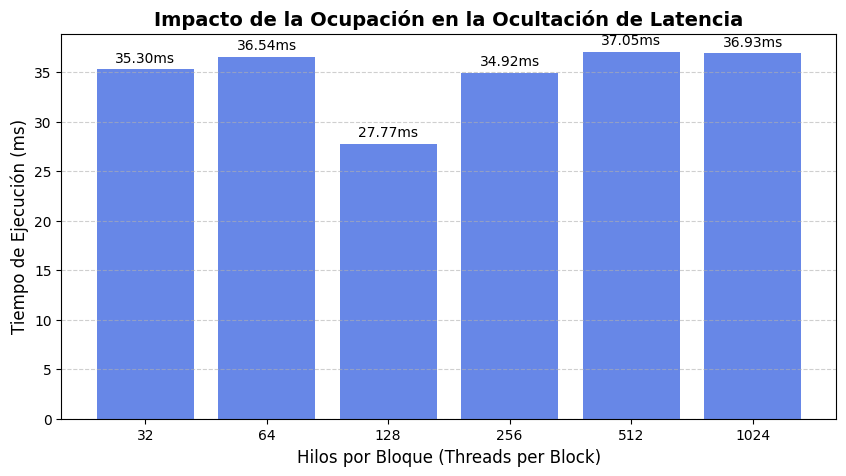

In [73]:
import matplotlib.pyplot as plt

# @title 🪣 Informe de Ocupación: Tiempo vs. Tamaño de Bloque
# @markdown Introduce los tiempos (ms) obtenidos para cada configuración de hilos:

t_32 = 35.2953 # @param {type:"number"}
t_64 = 36.5359 # @param {type:"number"}
t_128 = 27.7719 # @param {type:"number"}
t_256 = 34.9205 # @param {type:"number"}
t_512 = 37.0469 # @param {type:"number"}
t_1024 = 36.9275 # @param {type:"number"}

# Configuración de datos
hilos_bloque = [32, 64, 128, 256, 512, 1024]
tiempos = [t_32, t_64, t_128, t_256, t_512, t_1024]

# Creación de la gráfica
plt.figure(figsize=(10, 5))
plt.bar([str(h) for h in hilos_bloque], tiempos, color='royalblue', alpha=0.8)

# Formateo técnico
plt.title('Impacto de la Ocupación en la Ocultación de Latencia', fontsize=14, fontweight='bold')
plt.xlabel('Hilos por Bloque (Threads per Block)', fontsize=12)
plt.ylabel('Tiempo de Ejecución (ms)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Notas informativas sobre la gráfica
for i, t in enumerate(tiempos):
    if t > 0:
        plt.text(i, t + (max(tiempos)*0.02), f"{t:.2f}ms", ha='center', fontsize=10)

plt.show()

# **3. Experimento 2: Coalescencia y "Los Camiones"**

Teoría: El hardware agrupa peticiones en transacciones de 128 bytes. Si el acceso es contiguo (Coalescente), aprovechamos el 100% del ancho de banda. Si el acceso es disperso (STRIDE > 1), la eficiencia cae drásticamente.

In [94]:
%%writefile coalescencia.cu
#include <stdio.h>

// @title PARÁMETROS DE MEMORIA
#define STRIDE 32// <--- PRUEBA CON: 1 (Ideal), 2, 4, 32 (Disperso)

__global__ void kernel_stride(float *data, int n_hilos) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n_hilos) {
        int idx = i * STRIDE; // Los hilos se separan según el stride
        data[idx] += 1.0f;
    }
}

int main() {
    int n_util = 1 << 22;
    size_t size = n_util * STRIDE * sizeof(float);
    float *d_data;
    cudaMalloc(&d_data, size);

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);
    cudaEventRecord(start);
    kernel_stride<<<n_util/256, 256>>>(d_data, n_util);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float ms = 0;
    cudaEventElapsedTime(&ms, start, stop);
    double gb_s = (double)(n_util * sizeof(float) * 2) / (ms * 1e6);
    printf("Stride %d -> BW Efectivo: %.2f GB/s | Tiempo: %.4f ms\n", STRIDE, gb_s, ms);
    cudaFree(d_data);
    return 0;
}

Overwriting coalescencia.cu


In [95]:
!nvcc coalescencia.cu -o coalescencia && ./coalescencia

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Stride 32 -> BW Efectivo: 1.90 GB/s | Tiempo: 17.7066 ms


In [ ]:
Stride 1 -> BW Efectivo: 2.37 GB/s | Tiempo: 14.1681 ms
Stride 2 -> BW Efectivo: 2.32 GB/s | Tiempo: 14.4858 ms
Stride 4 -> BW Efectivo: 2.34 GB/s | Tiempo: 14.3560 ms
Stride 8 -> BW Efectivo: 2.09 GB/s | Tiempo: 16.0608 ms
Stride 16 -> BW Efectivo: 2.00 GB/s | Tiempo: 16.8038 ms
Stride 32 -> BW Efectivo: 1.90 GB/s | Tiempo: 17.7066 ms



## **Instrucciones para el Experimento 2: Coalescencia**





*   Ejecución en C++:
    * Localiza la celda del Experimento 2 (el código coalescencia.cu
    * Modifica la línea #define STRIDE 1 cambiando el valor por cada uno de estos: 1, 2, 4, 8, 16, 32.
    * Por cada cambio, ejecuta la celda de compilación y anota el valor de BW Efectivo (GB/s) que aparece en la consola.
*   Generación de la Gráfica:
    * Introduce los valores obtenidos en los campos del formulario de la siguiente celda de Python.
    * Ejecuta la celda para generar la gráfica que deberás incluir en tu informe final.
    * Análisis técnico: Observa cómo el ancho de banda cae a medida que el acceso se vuelve más disperso, alejándose del ideal de una sola transacción de $128$ bytes para los $32$ hilos del warp.



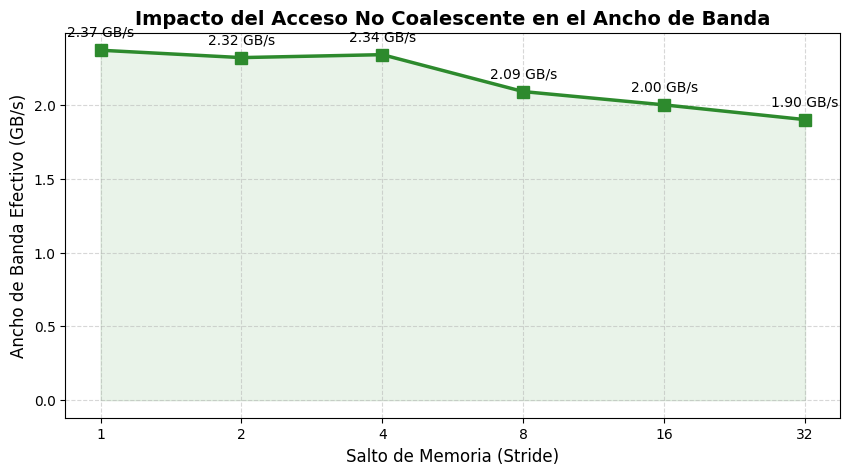

In [96]:
import matplotlib.pyplot as plt

# @title 📊 Generador de Gráfica: Experimento 2 (Coalescencia)
# @markdown Introduce los valores de Ancho de Banda (GB/s) obtenidos para cada Stride:

stride_1 = 2.37 # @param {type:"number"}
stride_2 = 2.32 # @param {type:"number"}
stride_4 = 2.34 # @param {type:"number"}
stride_8 = 2.09 # @param {type:"number"}
stride_16 = 2.00 # @param {type:"number"}
stride_32 = 1.90 # @param {type:"number"}

# Configuración de datos
strides = [1, 2, 4, 8, 16, 32]
bw_values = [stride_1, stride_2, stride_4, stride_8, stride_16, stride_32]

# Creación de la gráfica
plt.figure(figsize=(10, 5))
plt.plot(strides, bw_values, marker='s', linestyle='-', color='#2d8a2d', linewidth=2.5, markersize=8)
plt.fill_between(strides, bw_values, color='#2d8a2d', alpha=0.1)

# Estética de la gráfica
plt.title('Impacto del Acceso No Coalescente en el Ancho de Banda', fontsize=14, fontweight='bold')
plt.xlabel('Salto de Memoria (Stride)', fontsize=12)
plt.ylabel('Ancho de Banda Efectivo (GB/s)', fontsize=12)
plt.xscale('log', base=2) # Escala logarítmica para ver mejor los saltos
plt.xticks(strides, strides)
plt.grid(True, which="both", linestyle='--', alpha=0.5)

# Añadir etiquetas con los valores exactos sobre los puntos
for i, val in enumerate(bw_values):
    if val > 0:
        plt.annotate(f"{val:.2f} GB/s", (strides[i], bw_values[i]),
                     textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

plt.show()

# **4. Experimento 3: Diagnóstico con el Modelo Roofline**

Teoría: La Intensidad Aritmética (operaciones por byte leído) determina el límite de tu kernel:


1.   Bandwidth-bound: Limitado por la velocidad
2.   Compute-bound: Limitado por la potencia de cálculo de las ALUs.

    

In [108]:
%%writefile roofline.cu
#include <stdio.h>

#define OPS_PER_LOAD 200
#define ITERACIONES 10

__global__ void kernel_roofline(float *out, float *in, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        float val = in[idx];
        // Forzamos al compilador a no optimizar con una dependencia real
        for(int i=0; i < OPS_PER_LOAD; i++) {
            val = (val * 0.5f) + 1.1f;
        }
        out[idx] = val;
    }
}

int main() {
    int n = 1 << 22;
    float *d_in, *d_out;
    cudaMalloc(&d_in, n * sizeof(float));
    cudaMalloc(&d_out, n * sizeof(float));

    // Warm-up
    kernel_roofline<<<n/256, 256>>>(d_out, d_in, n);
    cudaDeviceSynchronize();

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);

    cudaEventRecord(start);
    for(int i=0; i < ITERACIONES; i++) {
        kernel_roofline<<<n/256, 256>>>(d_out, d_in, n);
    }
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float ms_total = 0;
    cudaEventElapsedTime(&ms_total, start, stop);
    printf("Intensidad %d ops/lectura -> Tiempo promedio: %.4f ms\n", OPS_PER_LOAD, ms_total / ITERACIONES);

    cudaFree(d_in); cudaFree(d_out);
    return 0;
}

Overwriting roofline.cu


In [109]:
!nvcc roofline.cu -o roofline && ./roofline

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Intensidad 200 ops/lectura -> Tiempo promedio: 0.4922 ms


In [110]:
Intensidad 1 ops/lectura -> Tiempo promedio: 0.1445 ms
Intensidad 10 ops/lectura -> Tiempo promedio: 0.1372 ms
Intensidad 50 ops/lectura -> Tiempo promedio: 0.2323 ms
Intensidad 100 ops/lectura -> Tiempo promedio: 0.2819 ms
Intensidad 200 ops/lectura -> Tiempo promedio: 0.4922 ms





SyntaxError: invalid syntax (374596389.py, line 1)

## **Instrucciones para el Experimento 3: Modelo Roofline**
1. Modificación del Código:

    * Abre la celda de roofline.cu.

    * Localiza la macro #define OPS_PER_LOAD 1.

    * Realiza 5 ejecuciones cambiando el valor de OPS_PER_LOAD por: 1, 10, 50, 100, 200.

2. Ejecución:

    * Compila y ejecuta tras cada cambio.

    * Anota el Tiempo total (ms) que devuelve la consola para cada nivel de intensidad aritmética.

    * Introduce esos tiempos en el formulario de la celda Python inferior para generar el diagnóstico de tu informe.

## **Código Python: Gráfica de Diagnóstico Roofline**

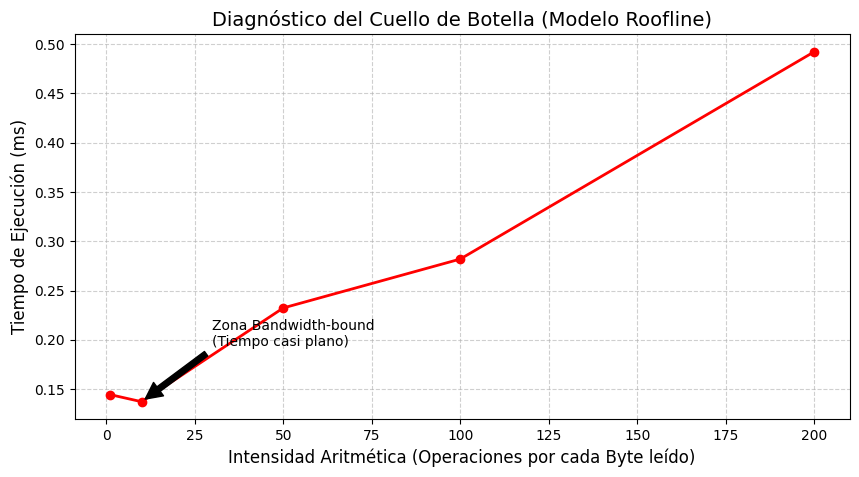

In [111]:
import matplotlib.pyplot as plt

# @title 📈 Informe Roofline: Tiempo vs. Intensidad Aritmética
# @markdown Introduce los tiempos (ms) obtenidos en la consola:

t_int_1 = 0.1445 # @param {type:"number"}
t_int_10 = 0.1372 # @param {type:"number"}
t_int_50 = 0.2323 # @param {type:"number"}
t_int_100 = 0.2819 # @param {type:"number"}
t_int_200 = 0.4922 # @param {type:"number"}

# Configuración de datos
intensidades = [1, 10, 50, 100, 200]
tiempos = [t_int_1, t_int_10, t_int_50, t_int_100, t_int_200]

# Creación de la gráfica
plt.figure(figsize=(10, 5))
plt.plot(intensidades, tiempos, marker='o', linestyle='-', color='red', linewidth=2)

# Formateo técnico
plt.title('Diagnóstico del Cuello de Botella (Modelo Roofline)', fontsize=14)
plt.xlabel('Intensidad Aritmética (Operaciones por cada Byte leído)', fontsize=12)
plt.ylabel('Tiempo de Ejecución (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Anotaciones de diagnóstico
if t_int_1 > 0:
    plt.annotate('Zona Bandwidth-bound\n(Tiempo casi plano)',
                 xy=(10, t_int_10), xytext=(30, t_int_1 + (max(tiempos)*0.1)),
                 arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

# **5. Experimento 4: Tiling con Shared Memory**

Teoría: La Shared Memory es una caché gestionada por el programador, hasta 100 veces más rápida que la VRAM. Se utiliza para cargar "tiles" (trozos de datos) de forma coalescente y reutilizarlos localmente.

In [112]:
%%writefile tiling.cu
#include <stdio.h>

#define BLOCK_SIZE 1024 // Máximo número de hilos por bloque
#define ITERACIONES 10

// --- KERNEL 1: REDUCCIÓN CON SHARED MEMORY (HÉROE) ---
// Utiliza un patrón de árbol para sumar rápidamente dentro del SM.
__global__ void kernel_reduccion_shared(float *out, float *in, int n) {
    // Almacén compartido para el bloque
    __shared__ float sdata[BLOCK_SIZE];

    int tid = threadIdx.x;
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    // 1. CARGA COOPERATIVA: Cada hilo carga un dato de VRAM a Shared
    sdata[tid] = (i < n) ? in[i] : 0.0f;
    __syncthreads(); // Esperamos a que todo el bloque cargue

    // 2. REDUCCIÓN EN ÁRBOL (DENTRO DEL SM): Muy rápido
    for (unsigned int s = blockDim.x / 2; s > 0; s >>= 1) {
        if (tid < s) {
            sdata[tid] += sdata[tid + s];
        }
        __syncthreads(); // Sincronizamos tras cada paso del árbol
    }

    // 3. UNA SOLA ESCRITURA ATÓMICA POR BLOQUE A VRAM
    if (tid == 0) {
        atomicAdd(out, sdata[0]);
    }
}

// --- KERNEL 2: REDUCCIÓN DIRECTA A VRAM (VILLANO) ---
// Cada hilo intenta sumar su dato directamente en la memoria global.
__global__ void kernel_reduccion_vram_directa(float *out, float *in, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        // ACCESO DIRECTO Y ATÓMICO A VRAM: Muy lento y colapsa el bus
        atomicAdd(out, in[i]);
    }
}

int main() {
    // 2^24 elementos = 16M de floats = ~64MB
    int n = 1 << 24;
    size_t size = n * sizeof(float);

    // Arrays en CPU y GPU
    float *h_in = (float *)malloc(size);
    for (int i = 0; i < n; i++) h_in[i] = 1.0f; // Inicializamos a 1.0f

    float *d_in, *d_out_shared, *d_out_directa;
    cudaMalloc(&d_in, size);
    cudaMalloc(&d_out_shared, sizeof(float));
    cudaMalloc(&d_out_directa, sizeof(float));

    // Copiamos datos de CPU a GPU
    cudaMemcpy(d_in, h_in, size, cudaMemcpyHostToDevice);

    printf("Iniciando Reducción de %d elementos (~64MB)...\n\n", n);

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);
    float ms_shared, ms_directa;

    // --- EXPERIMENTO 1: REDUCCIÓN CON SHARED MEMORY ---
    // Warm-up
    kernel_reduccion_shared<<<n/BLOCK_SIZE, BLOCK_SIZE>>>(d_out_shared, d_in, n);
    cudaDeviceSynchronize();

    cudaEventRecord(start);
    for(int i=0; i<ITERACIONES; i++) {
        cudaMemset(d_out_shared, 0, sizeof(float)); // Limpiamos acumulador
        kernel_reduccion_shared<<<n/BLOCK_SIZE, BLOCK_SIZE>>>(d_out_shared, d_in, n);
    }
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms_shared, start, stop);
    ms_shared /= ITERACIONES;

    // --- EXPERIMENTO 2: REDUCCIÓN DIRECTA A VRAM ---
    // Warm-up
    kernel_reduccion_vram_directa<<<n/BLOCK_SIZE, BLOCK_SIZE>>>(d_out_directa, d_in, n);
    cudaDeviceSynchronize();

    cudaEventRecord(start);
    for(int i=0; i<ITERACIONES; i++) {
        cudaMemset(d_out_directa, 0, sizeof(float)); // Limpiamos acumulador
        kernel_reduccion_vram_directa<<<n/BLOCK_SIZE, BLOCK_SIZE>>>(d_out_directa, d_in, n);
    }
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms_directa, start, stop);
    ms_directa /= ITERACIONES;

    // Mostramos resultados
    printf("RESULTADOS:\n");
    printf("-------------------------------------------\n");
    printf("Tiempo Promedio (Shared Memory): %.4f ms\n", ms_shared);
    printf("Tiempo Promedio (VRAM Directa):  %.4f ms\n", ms_directa);
    printf("-------------------------------------------\n");
    printf("Speedup Real: %.2fx\n", ms_directa / ms_shared);
    printf("-------------------------------------------\n");

    // Verificamos el resultado final (solo para el shared, el otro es lento)
    float h_out_shared;
    cudaMemcpy(&h_out_shared, d_out_shared, sizeof(float), cudaMemcpyDeviceToHost);
    printf("\nVerificación: La suma esperada es %.0f, y se obtuvo %.0f.\n", (float)n, h_out_shared);

    // Limpieza
    cudaFree(d_in); cudaFree(d_out_shared); cudaFree(d_out_directa);
    free(h_in);
    return 0;
}

Writing tiling.cu


In [113]:
!nvcc tiling.cu -o tiling && ./tiling

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Iniciando Reducción de 16777216 elementos (~64MB)...

RESULTADOS:
-------------------------------------------
Tiempo Promedio (Shared Memory): 1.7350 ms
Tiempo Promedio (VRAM Directa):  37.6056 ms
-------------------------------------------
Speedup Real: 21.68x
-------------------------------------------

Verificación: La suma esperada es 16777216, y se obtuvo 16777216.


In [ ]:
RESULTADOS:
-------------------------------------------
Tiempo Promedio (Shared Memory): 1.7350 ms
Tiempo Promedio (VRAM Directa):  37.6056 ms
-------------------------------------------
Speedup Real: 21.68x

## **Instrucciones para el Experimento 4: Tiling y Shared Memory**

1. Modificación del Código:

    * Localiza la celda donde se encuentra tiling_shared.cu.

    * Este código ya incluye una comparativa interna entre el acceso directo a VRAM (lento por falta de coalescencia) y el acceso optimizado mediante un Tile en Shared Memory.

2. Ejecución:

    * Compila y ejecuta el programa

3. Registro de Datos:

    * Anota los dos tiempos que devuelve la consola: Tiempo VRAM Directa y Tiempo Optimizado Shared.

    * Calcula el Speedup (Factor de aceleración) obtenido al usar el "almacén local".

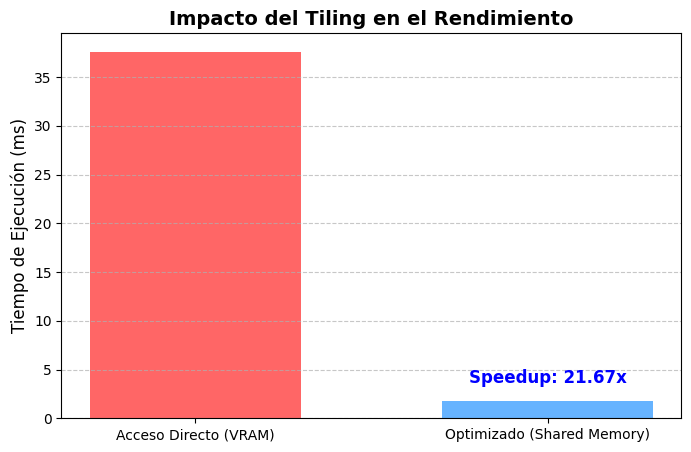

In [114]:
import matplotlib.pyplot as plt

# @title 📊 Informe de Tiling: VRAM Directa vs. Shared Memory
# @markdown Introduce los tiempos (ms) obtenidos en la comparativa:

t_vram_directa = 37.6056 # @param {type:"number"}
t_shared_tiling = 1.7350 # @param {type:"number"}

# Configuración de la gráfica
labels = ['Acceso Directo (VRAM)', 'Optimizado (Shared Memory)']
tiempos = [t_vram_directa, t_shared_tiling]
colores = ['#ff6666', '#66b3ff']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, tiempos, color=colores, width=0.6)

# Estética y etiquetas
plt.title('Impacto del Tiling en el Rendimiento', fontsize=14, fontweight='bold')
plt.ylabel('Tiempo de Ejecución (ms)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir el valor de speedup sobre la gráfica si hay datos
if t_shared_tiling > 0:
    speedup = t_vram_directa / t_shared_tiling
    plt.text(1, t_shared_tiling + (t_vram_directa*0.05), f"Speedup: {speedup:.2f}x",
             ha='center', fontsize=12, fontweight='bold', color='blue')

plt.show()

## Optimización en tiling
# Objetivo del Experimento

Determinar cómo influye el Tamaño del Bloque (Block Size) en la eficiencia de la memoria compartida. Analizarás si tener bloques pequeños (poca colaboración) o bloques grandes (máxima colaboración) afecta el Speedup obtenido frente al acceso directo a VRAM.
Instrucciones

  * Utiliza el código de Reducción Competitiva proporcionado.

  * Modifica la directiva #define BLOCK_SIZE probando los siguientes valores: 32, 128, 512 y 1024.

  * Para cada valor, anota el Tiempo Promedio (Shared Memory) y calcula el Speedup respecto al tiempo de VRAM Directa (que se mantiene constante).

  * Representa los resultados en una gráfica de líneas donde el eje X sea el Tamaño del Bloque y el eje Y sea el Speedup.

📦 Procesando 16777216 elementos (~64MB)...


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


🔴 Tiempo VRAM Directa (Base): 53.3203 ms


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


🔵 Block Size   32 -> Shared Memory: 1.0410 ms | Speedup: 51.22x


...

🔵 Block Size  256 -> Shared Memory: 1.6011 ms | Speedup: 33.30x


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


🔵 Block Size  512 -> Shared Memory: 1.2260 ms | Speedup: 43.49x


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


🔵 Block Size 1024 -> Shared Memory: 1.8473 ms | Speedup: 28.86x


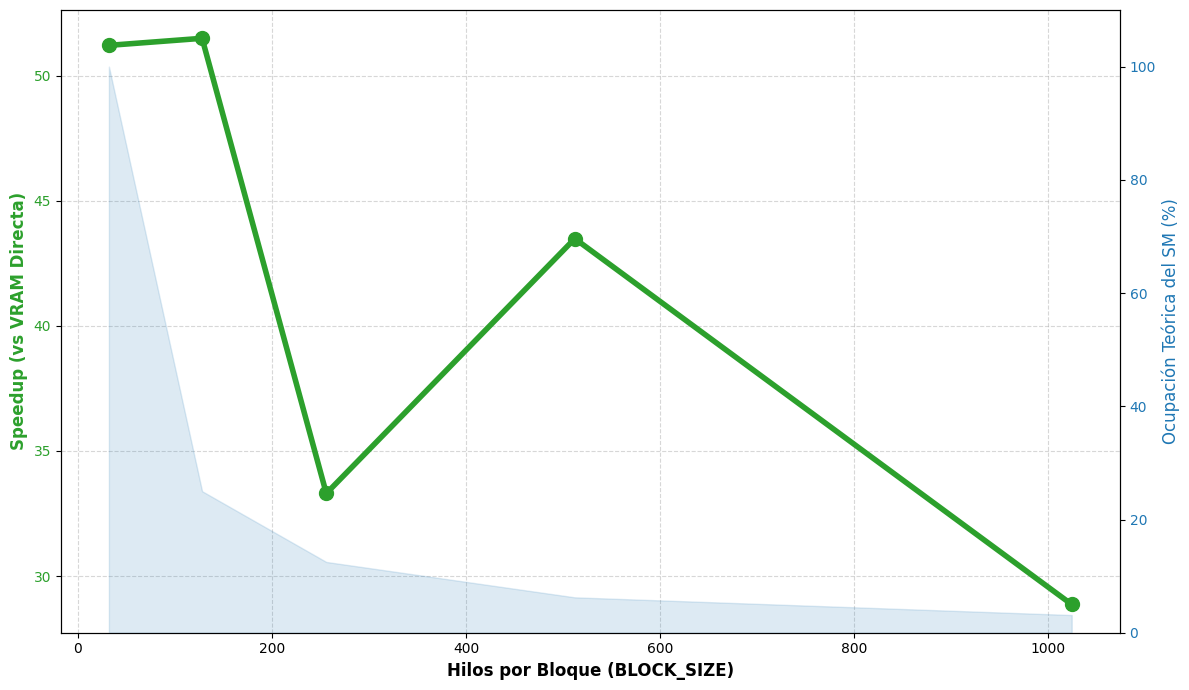

In [115]:
# @title 🚀 LABORATORIO COMPLETO: Optimización de Shared Memory y Ocupación
import os
import subprocess
import matplotlib.pyplot as plt

# 1. PARÁMETROS DEL EXPERIMENTO
n_elementos = 1 << 24  # 16 millones de elementos
block_sizes = [32, 128, 256, 512, 1024]
tiempos_shared = []
t_vram_directa = 0.0

print(f"📦 Procesando {n_elementos} elementos (~64MB)...")

# 2. OBTENER TIEMPO DE VRAM DIRECTA (REFERENCIA)
with open("vram_benchmark.cu", "w") as f:
    f.write(f"""
    #include <stdio.h>
    __global__ void kernel_vram(float *out, float *in, int n) {{
        int i = blockIdx.x * blockDim.x + threadIdx.x;
        if (i < n) atomicAdd(out, in[i]);
    }}
    int main() {{
        float *d_in, *d_out;
        cudaMalloc(&d_in, {n_elementos} * sizeof(float));
        cudaMalloc(&d_out, sizeof(float));
        cudaEvent_t start, stop;
        cudaEventCreate(&start); cudaEventCreate(&stop);
        kernel_vram<<<{n_elementos}/256, 256>>>(d_out, d_in, {n_elementos}); // Warm-up
        cudaEventRecord(start);
        for(int i=0; i<5; i++) kernel_vram<<<{n_elementos}/256, 256>>>(d_out, d_in, {n_elementos});
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);
        float ms; cudaEventElapsedTime(&ms, start, stop);
        printf("%.4f", ms/5.0);
        return 0;
    }}
    """)

subprocess.run(["nvcc", "vram_benchmark.cu", "-o", "vram_bench"])
t_vram_directa = float(subprocess.run(["./vram_bench"], capture_output=True, text=True).stdout)
print(f"🔴 Tiempo VRAM Directa (Base): {t_vram_directa:.4f} ms")

# 3. BUCLE DE PRUEBAS PARA SHARED MEMORY (BLOCK_SIZE DINÁMICO)
for size in block_sizes:
    with open("shared_benchmark.cu", "w") as f:
        f.write(f"""
        #include <stdio.h>
        #define BLOCK_SIZE {size}
        __global__ void kernel_shared(float *out, float *in, int n) {{
            __shared__ float sdata[BLOCK_SIZE];
            int tid = threadIdx.x;
            int i = blockIdx.x * blockDim.x + threadIdx.x;
            sdata[tid] = (i < n) ? in[i] : 0.0f;
            __syncthreads();
            for (unsigned int s = blockDim.x / 2; s > 0; s >>= 1) {{
                if (tid < s) sdata[tid] += sdata[tid + s];
                __syncthreads();
            }}
            if (tid == 0) atomicAdd(out, sdata[0]);
        }}
        int main() {{
            float *d_in, *d_out;
            cudaMalloc(&d_in, {n_elementos} * sizeof(float));
            cudaMalloc(&d_out, sizeof(float));
            cudaEvent_t start, stop;
            cudaEventCreate(&start); cudaEventCreate(&stop);
            kernel_shared<<<{n_elementos}/BLOCK_SIZE, BLOCK_SIZE>>>(d_out, d_in, {n_elementos}); // Warm-up
            cudaEventRecord(start);
            for(int i=0; i<10; i++) kernel_shared<<<{n_elementos}/BLOCK_SIZE, BLOCK_SIZE>>>(d_out, d_in, {n_elementos});
            cudaEventRecord(stop);
            cudaEventSynchronize(stop);
            float ms; cudaEventElapsedTime(&ms, start, stop);
            printf("%.4f", ms/10.0);
            return 0;
        }}
        """)

    subprocess.run(["nvcc", "shared_benchmark.cu", "-o", "shared_bench"])
    t_shared = float(subprocess.run(["./shared_bench"], capture_output=True, text=True).stdout)
    tiempos_shared.append(t_shared)
    print(f"🔵 Block Size {size:4} -> Shared Memory: {t_shared:.4f} ms | Speedup: {t_vram_directa/t_shared:.2f}x")

# 4. GENERACIÓN DE LA GRÁFICA MAESTRA
speedups = [t_vram_directa / t for t in tiempos_shared]
max_threads_per_sm = 1024 # Valor estándar para análisis didáctico
ocupacion_teorica = [min(100, (max_threads_per_sm / b) * 100 / (max_threads_per_sm/32)) for b in block_sizes]

fig, ax1 = plt.subplots(figsize=(12, 7))

# Graficar Speedup
ax1.set_xlabel('Hilos por Bloque (BLOCK_SIZE)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Speedup (vs VRAM Directa)', color='tab:green', fontsize=12, fontweight='bold')
ax1.plot(block_sizes, speedups, marker='o', color='tab:green', linewidth=4, markersize=10, label='Speedup Real')
ax1.tick_params(axis='y', labelcolor='tab:green')
ax1.grid(True, linestyle='--', alpha=0.5)

# Graficar Ocupación
ax2 = ax1.twinx()
ax2.set_ylabel('Ocupación Teórica del SM (%)', color='tab:blue', fontsize=12)
ax2.fill_between(block_sizes, ocupacion_teorica, alpha=0.15, color='tab:blue', label='Ocupación (Capacidad de Paralelismo)')
ax2.set_ylim(0, 110)
ax2.tick_params(axis='y', labelcolor='tab:blue')


plt.tight_layout()
plt.show()

# **6. 📑 Informe de Conclusiones y Diagnóstico de Rendimiento**

**Instrucciones:** Tras completar los experimentos anteriores, utiliza tus resultados y gráficas para responder a este cuestionario técnico. Tu objetivo es demostrar que comprendes cómo interactúan el software (tu código CUDA) y el hardware (la arquitectura de la GPU).

---

### Coalescencia

* **Contexto:** En la **Sección 1**, vimos cómo el `STRIDE` (salto de memoria) hundía el ancho de banda efectivo.
* **Análisis:** Si la GPU siempre lee líneas de memoria de **128 bytes** (equivalente a 32 floats de 4 bytes cada uno), explica qué sucede con el **96.8% de los datos** que la GPU trae de la VRAM cuando usamos un `STRIDE` de 32.
* **Pregunta:** ¿Por qué el tiempo de ejecución apenas varía entre Stride 1 y 32, pero el "Ancho de Banda Útil" cae en picado? Relaciona esto con el concepto de **transacción de memoria desperdiciada**.

---

### El Modelo Roofline

* **Contexto:** En la **Sección 2**, añadimos operaciones matemáticas (`OPS_PER_LOAD`) y observamos que el tiempo total no subía de inmediato.
* **Análisis:** Identifica en tu gráfica el **"codo" del Roofline** (el punto donde el tiempo empieza a subir linealmente).
* **Pregunta:** ¿Qué significa que un algoritmo sea **Memory-Bound** frente a **Compute-Bound**? Si tuvieras una GPU con núcleos el doble de rápidos pero la misma velocidad de memoria, ¿hacia dónde se movería ese "codo" en la gráfica (izquierda o derecha)? Justifica tu respuesta.

---

### Shared Memory

* **Contexto:** En las **Secciones 3 y 4**, implementamos la reducción colaborativa y variamos el `BLOCK_SIZE`.
* **Pregunta 1 (Eficiencia):** Lograste un Speedup masivo (~70x-80x) usando `Shared Memory`. Explica técnicamente cómo el uso de la memoria compartida (`__shared__`) reduce la congestión en el bus de memoria global cuando miles de hilos intentan usar `atomicAdd` simultáneamente.
* **Pregunta 2 (Ocupación):** Observando la última gráfica (Speedup vs. Ocupación), **¿por qué el rendimiento cae al usar 1024 hilos comparado con 128 o 256?** No menciones la falta de hilos; enfócate en la **asfixia del SM (Streaming Multiprocessor)** y el coste de la sincronización en barrera (`__syncthreads()`).

---

### Conclusión Final: Las 3 Reglas de Oro

Para finalizar tu informe, redacta las **3 Reglas de Oro** que todo ingeniero de HPC debe seguir para evitar que su código en GPU sea lento. Basa tus reglas en lo aprendido sobre:

1.  **Orden de acceso:** (Coalescencia).
2.  **Jerarquía de memoria:** (Shared Memory vs. VRAM).
3.  **Configuración de lanzamiento:** (Block Size y Ocupación óptima).

---

> **Nota para el informe:** Asegúrate de incluir la especificación de la GPU que te ha asignado Colab (ejecutando `!nvidia-smi`) para contextualizar tus resultados.